<a href="https://colab.research.google.com/github/VamuveTV/3DTrajMaster/blob/main/GugaDeOldify_ImageColorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeOldify Image Colorization Batch Processer

This is a batch processor for [DeOldify](https://github.com/jantic/DeOldify) to be run in Google Colaboratory, using Google Drive as data storage.

### Tips
- `input` may be a file path or a directory path. If a directory path given, all images in the directory will be processed.
- if `output_dir` is not given, images will be saved to `<input_dir>/colorized`
- Set all direcotries relative to your Google Drive root, e.g. `images/grayscale` and `images/colorized` if you have a directory called _images_ in your Drive, containing directory _grayscale_.




In [3]:
# @title #1. Setup DeOldify (Clean Install)
import os
import collections
import torch

# --- CLEANUP BROKEN FILES ---
!rm -rf /content/DeOldify/models/*.pth

# Fix Python 3.12 compatibility
if not hasattr(collections, 'Iterable'):
    import collections.abc
    collections.Iterable = collections.abc.Iterable

# Configuration
%cd /content/
if not os.path.exists('/content/DeOldify'):
    !git clone https://github.com/jantic/DeOldify.git
%cd /content/DeOldify

# Install dependencies
!pip install -q fastai==1.0.60 ffmpeg-python==0.2.0 yt-dlp tensorboardX==2.6.5

# --- DOWNLOAD MODELS (versão confiável) ---
print("Downloading models... this may take a couple of minutes.")

!mkdir -p 'models'

# Artistic model (recomendado)
print("Baixando ColorizeArtistic_gen.pth...")
!wget -q --show-progress --no-check-certificate -c \
  "https://huggingface.co/databuzzword/deoldify-artistic/resolve/main/ColorizeArtistic_gen.pth" \
  -O ./models/ColorizeArtistic_gen.pth || \
!wget -q --show-progress --no-check-certificate -c \
  "https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth" \
  -O ./models/ColorizeArtistic_gen.pth

# Stable model
print("Baixando ColorizeStable_gen.pth...")
!wget -q --show-progress --no-check-certificate -c \
  "https://www.dropbox.com/s/usf7uifrctqw9rl/ColorizeStable_gen.pth?dl=1" \
  -O ./models/ColorizeStable_gen.pth || \
echo "Stable model download had issues, continuing anyway..."

# Verificação dos modelos
print("\nVerificando tamanho dos modelos baixados:")
!ls -lh ./models/
!test -f ./models/ColorizeArtistic_gen.pth && echo "✅ Artistic model OK (~255 MB esperado)" || echo "❌ Artistic model missing"

# Mount Drive
if not os.path.isdir('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

from deoldify import device
from deoldify.device_id import DeviceId
device.set(device=DeviceId.GPU0)

from deoldify.visualize import *
from google.colab import output
output.clear()

print('✅ Setup Complete!')
print('Tamanho dos modelos:')
!ls -lh models/

✅ Setup Complete!
Tamanho dos modelos:
total 7.7G
-rw-r--r-- 1 root root 244M Apr 20 05:36 ColorizeArtistic_gen.pth
-rw-r--r-- 1 root root 101K Apr 20 05:36 ColorizeStable_gen.pth
-rw------- 1 root root 1.5G Apr 20 05:13 tmp67be2dy7
-rw------- 1 root root 1.5G Apr 20 05:08 tmp7mz324r4
-rw------- 1 root root 1.5G Apr 20 05:14 tmpx0sn5ee1
-rw------- 1 root root 1.5G Apr 20 05:13 tmpxw0_677z
-rw------- 1 root root 1.5G Apr 20 05:12 tmpzrticpw9


📸 Encontradas 2 imagens. Iniciando colorização...


/content/DeOldify/fastai/data_block.py:451: UserWarning: Your training set is empty. If this is by design, pass `ignore_empty=True` to remove this warning.
  warn("Your training set is empty. If this is by design, pass `ignore_empty=True` to remove this warning.")
/content/DeOldify/fastai/data_block.py:453: UserWarning: Your validation set is empty. If this is by design, use `split_none()`
                 or pass `ignore_empty=True` when labelling to remove this warning.
  warn("""Your validation set is empty. If this is by design, use `split_none()`
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  se

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 64.2MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


🎨 Colorizando: FotoMAisClara da Mao669614410_10233046210517365_5188307946958282750_n.jpg
✅ Salvo em: images/colorized/FotoMAisClara da Mao669614410_10233046210517365_5188307946958282750_n.jpg
🎨 Colorizando: FotoMao666047742_946845964624097_6402307347059518418_n.jpg
✅ Salvo em: images/colorized/FotoMao666047742_946845964624097_6402307347059518418_n.jpg

✅ Processo finalizado! Resultados salvos em: images/colorized


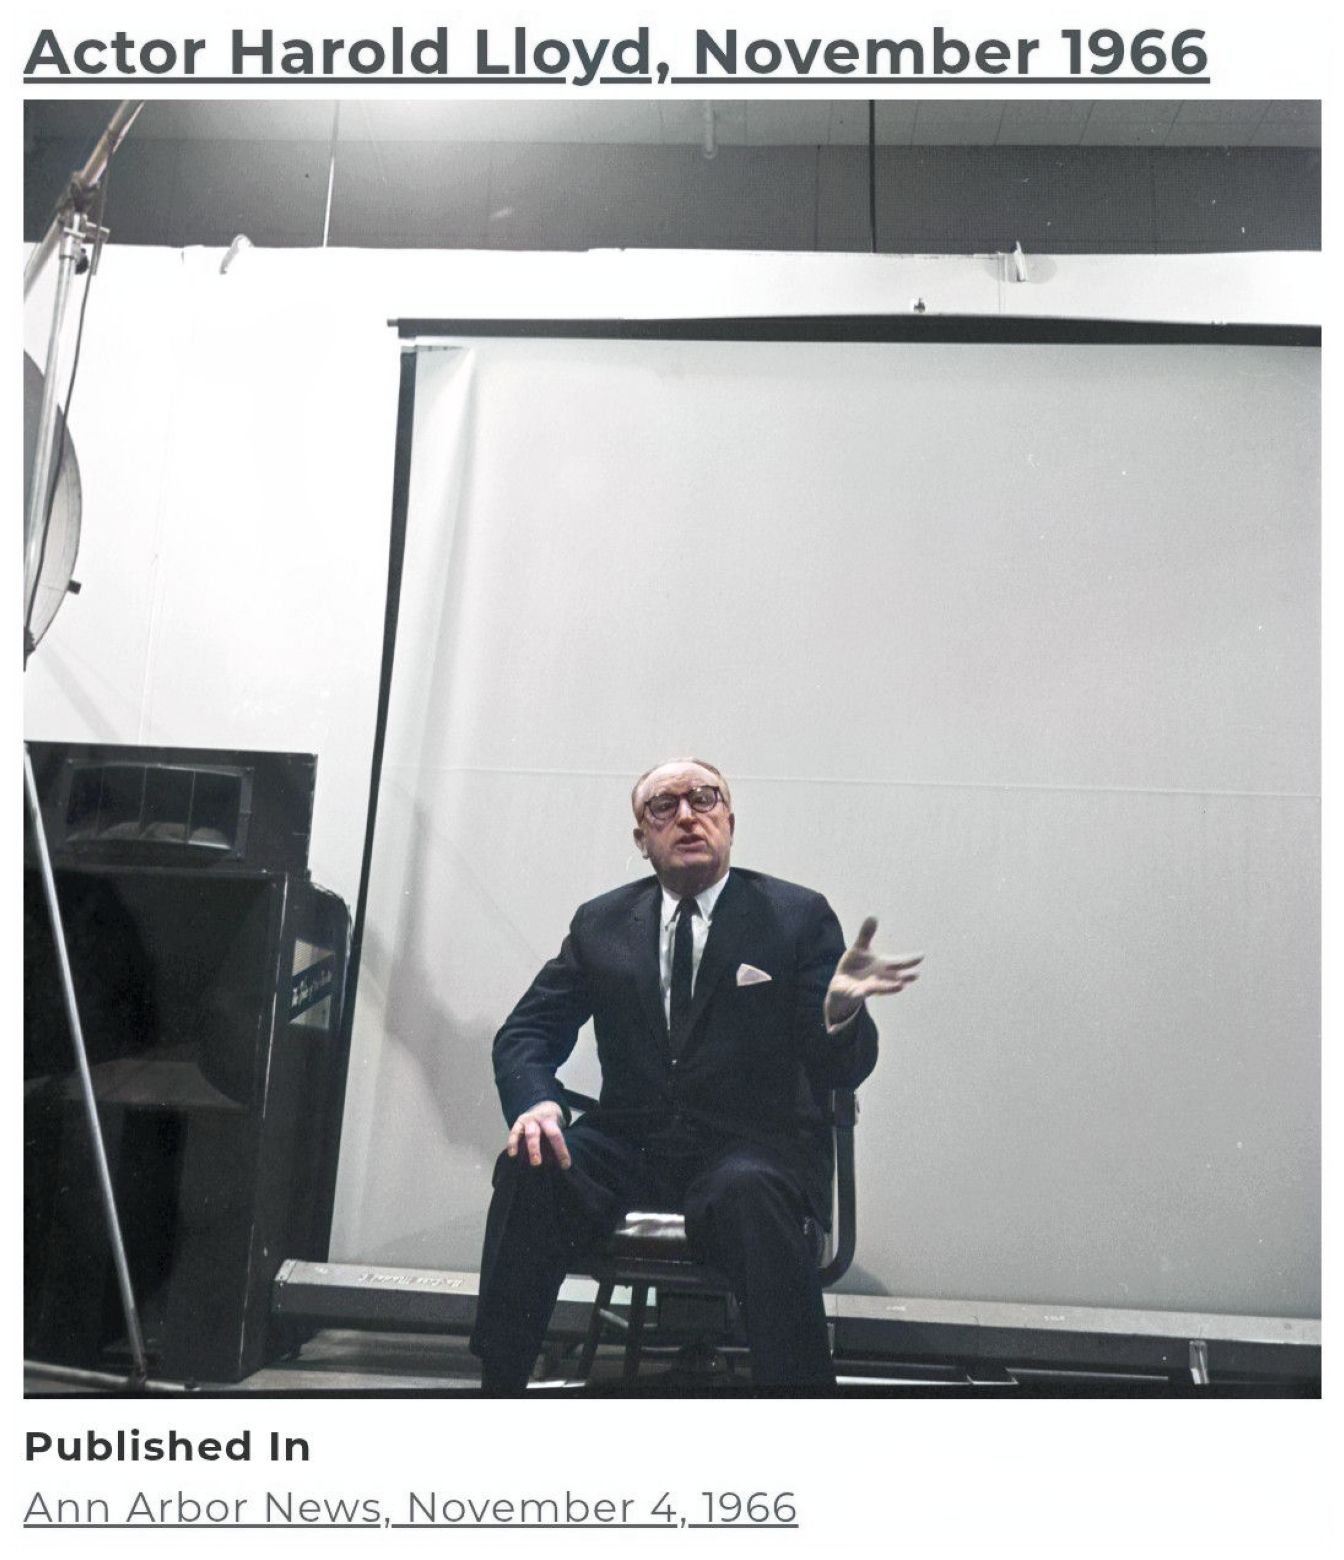

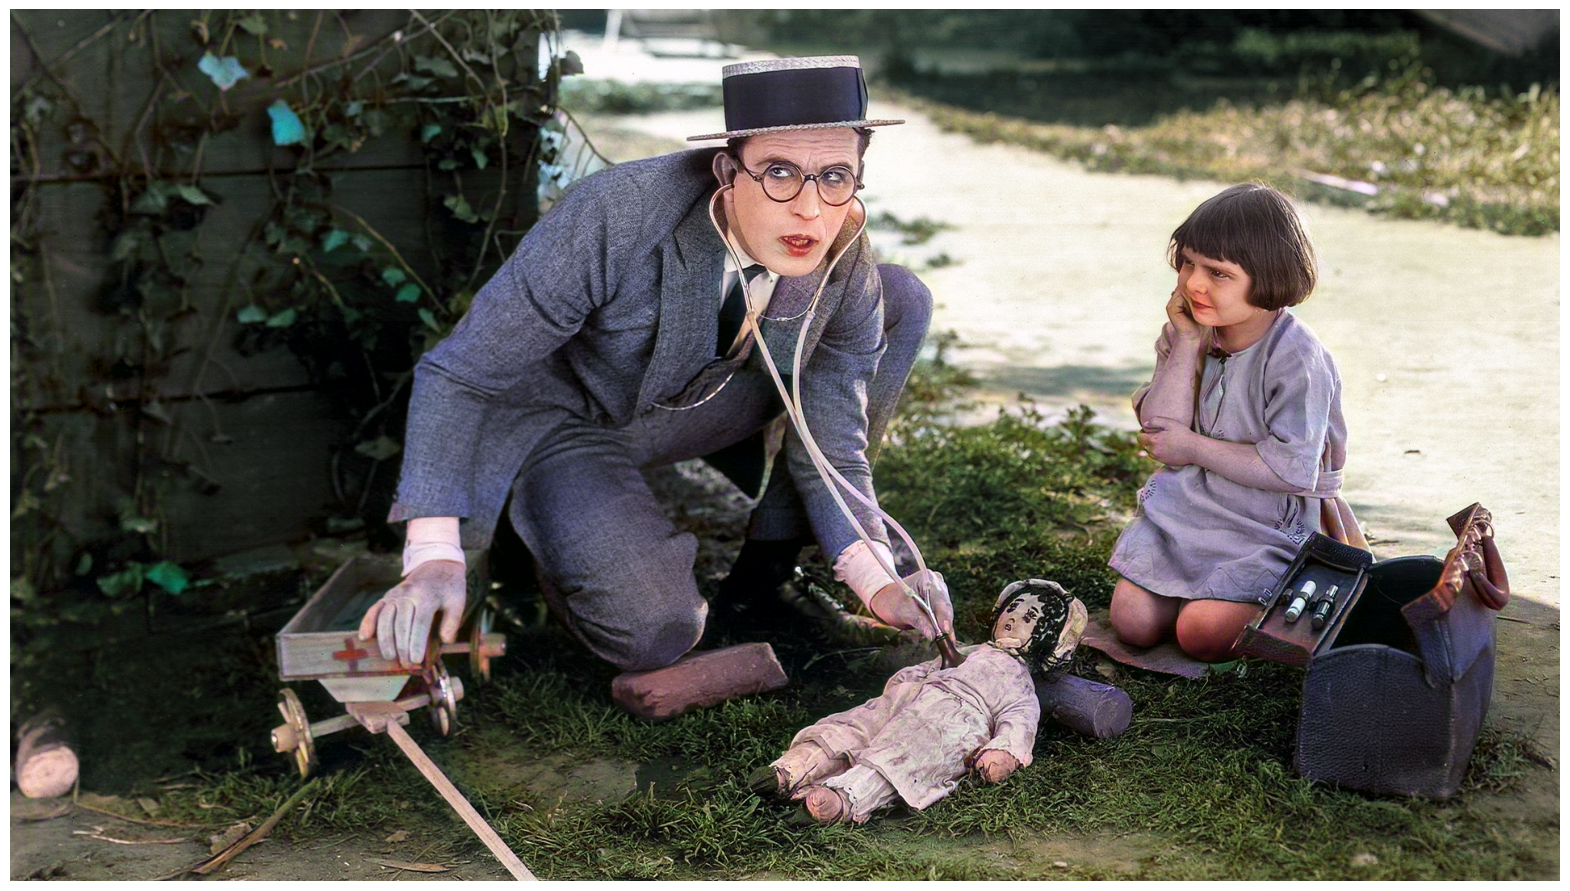

In [4]:
# @title #2. Colorize Images
import torch
import os
from PIL import Image

# === BYPASS TORCH.LOAD (para evitar UnpicklingError) ===
original_load = torch.load

def safe_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return original_load(*args, **kwargs)

torch.load = safe_load
import torch.serialization
torch.serialization.load = safe_load

# Import DeOldify
from deoldify.visualize import *

# --- SETTINGS ---
input_folder = "images/grayscale" #@param {type: "string"}
output_folder = "images/colorized" #@param {type: "string"}
use_artistic = True #@param {type:"boolean"}
render_factor = 35 #@param {type: "slider", min: 7, max: 40}

# Paths no Google Drive
drive_path = "/content/drive/My Drive/"
in_full = os.path.join(drive_path, input_folder)
out_full = os.path.join(drive_path, output_folder)

if not os.path.exists(in_full):
    print(f"❌ Pasta não encontrada: {in_full}")
    print("Crie a pasta 'images/grayscale' no seu Google Drive e coloque as imagens em PB nela.")
else:
    if not os.path.exists(out_full):
        os.makedirs(out_full)

    pics = [f for f in os.listdir(in_full) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))]

    if not pics:
        print("❌ Nenhuma imagem encontrada na pasta.")
    else:
        print(f"📸 Encontradas {len(pics)} imagens. Iniciando colorização...")

        colorizer = get_image_colorizer(artistic=use_artistic)

        for p in pics:
            print(f"🎨 Colorizando: {p}")
            try:
                img_path = colorizer.plot_transformed_image(
                    path=os.path.join(in_full, p),
                    render_factor=render_factor,
                    compare=False,
                    watermarked=False
                )
                if img_path and os.path.exists(img_path):
                    result = Image.open(img_path)
                    result.save(os.path.join(out_full, p))
                    print(f"✅ Salvo em: {output_folder}/{p}")
                else:
                    print(f"⚠️ Não gerou imagem para {p}")
            except Exception as e:
                print(f"❌ Erro ao colorizar {p}: {str(e)}")

        print(f"\n✅ Processo finalizado! Resultados salvos em: {output_folder}")

# Restaura o torch.load original
torch.load = original_load